# Full Model Evaluation on Held-Out Test Set

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [2]:
BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / 'models'
DATA_DIR = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = ['Low', 'Medium', 'High']

model_paths = {
    'Decision Tree': MODELS_DIR / 'decision_tree.joblib',
    'Logistic Regression': MODELS_DIR / 'logistic_regression.joblib',
    'Neural Network MLP': MODELS_DIR / 'neural_network_mlp.joblib',
    'Random Forest': MODELS_DIR / 'random_forest.joblib',
}

models = {name: joblib.load(path) for name, path in model_paths.items()}

X_test = pd.read_csv(DATA_DIR / 'X_test.csv')
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').iloc[:, 0]

print(f'Loaded {len(models)} models')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

Loaded 4 models
X_test shape: (8008, 14)
y_test shape: (8008,)


In [3]:
predictions = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    predictions[model_name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
    }

    print(f'{model_name}: generated predictions and probabilities')

Decision Tree: generated predictions and probabilities
Logistic Regression: generated predictions and probabilities


Neural Network MLP: generated predictions and probabilities


Random Forest: generated predictions and probabilities


In [4]:
metrics_rows = []

for model_name, outputs in predictions.items():
    y_pred = outputs['y_pred']
    y_proba = outputs['y_proba']

    metrics_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Weighted)': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall (Weighted)': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score (Weighted)': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'ROC-AUC (OvR Weighted)': roc_auc_score(
            y_test,
            y_proba,
            labels=CLASS_LABELS,
            multi_class='ovr',
            average='weighted',
        ),
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model')

print('Model Evaluation Metrics')
display(metrics_df.round(4))
display(metrics_df.style.highlight_max(axis=0).format('{:.4f}'))

Model Evaluation Metrics


,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),ROC-AUC (OvR Weighted)
Model,,,,,
Decision Tree,0.9170,0.9170,0.9170,0.9167,0.9299
Logistic Regression,0.8764,0.8810,0.8764,0.8753,0.9339
Neural Network MLP,0.9175,0.9175,0.9175,0.9172,0.9433
Random Forest,0.9245,0.9247,0.9245,0.9242,0.9467


,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),ROC-AUC (OvR Weighted)
Model,,,,,
Decision Tree,0.9170,0.9170,0.9170,0.9167,0.9299
Logistic Regression,0.8764,0.8810,0.8764,0.8753,0.9339
Neural Network MLP,0.9175,0.9175,0.9175,0.9172,0.9433
Random Forest,0.9245,0.9247,0.9245,0.9242,0.9467


In [5]:
for model_name, outputs in predictions.items():
    print('=' * 80)
    print(f'Classification Report ? {model_name}')
    print('=' * 80)
    print(classification_report(
        y_test,
        outputs['y_pred'],
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    ))

Classification Report ? Decision Tree
              precision    recall  f1-score   support

         Low       0.91      0.89      0.90      2065
      Medium       0.92      0.95      0.93      3876
        High       0.93      0.88      0.90      2067

    accuracy                           0.92      8008
   macro avg       0.92      0.91      0.91      8008
weighted avg       0.92      0.92      0.92      8008

Classification Report ? Logistic Regression
              precision    recall  f1-score   support

         Low       0.90      0.78      0.83      2065
      Medium       0.84      0.95      0.89      3876
        High       0.94      0.83      0.88      2067

    accuracy                           0.88      8008
   macro avg       0.89      0.85      0.87      8008
weighted avg       0.88      0.88      0.88      8008

Classification Report ? Neural Network MLP
              precision    recall  f1-score   support

         Low       0.91      0.89      0.90      2065
    

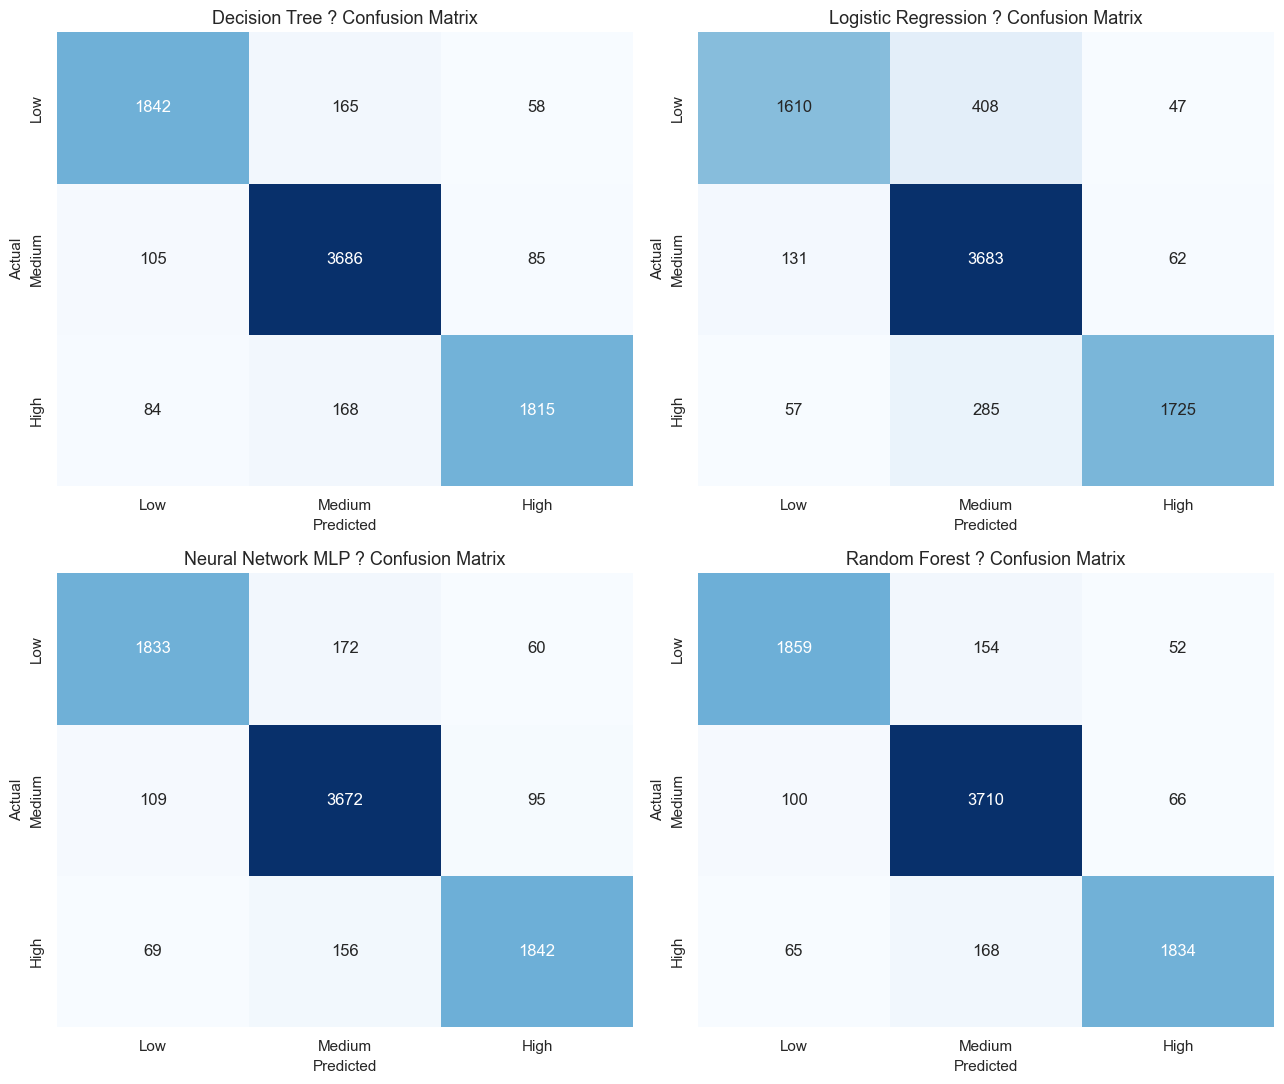

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()

for ax, (model_name, outputs) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, outputs['y_pred'], labels=CLASS_LABELS)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar=False,
        ax=ax,
    )
    ax.set_title(f'{model_name} ? Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

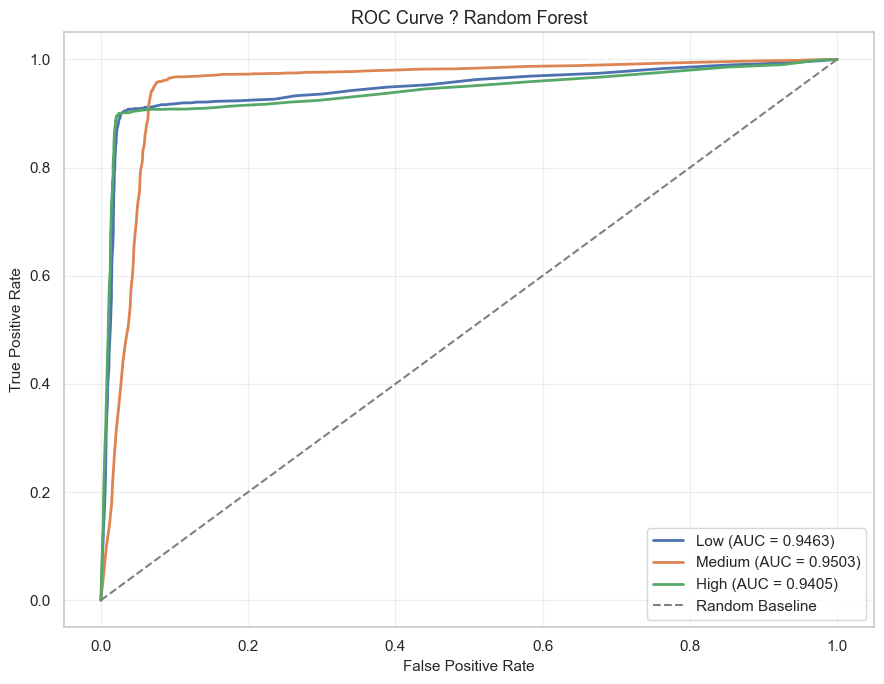

In [7]:
best_model_name = metrics_df['F1-Score (Weighted)'].idxmax()
best_outputs = predictions[best_model_name]
y_test_binarized = label_binarize(y_test, classes=CLASS_LABELS)
y_proba = best_outputs['y_proba']

plt.figure(figsize=(9, 7))

for class_index, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, class_index], y_proba[:, class_index])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {class_auc:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Baseline')
plt.title(f'ROC Curve ? {best_model_name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
best_metrics = metrics_df.loc[best_model_name]

print('''
## Winner Summary
| Field | Value |
|---|---|
| Best Model | {model_name} |
| Test F1-Score (Weighted) | {f1:.4f} |
| Test Accuracy | {accuracy:.4f} |
| Test ROC-AUC (OvR Weighted) | {roc_auc:.4f} |

Business interpretation: For BabiPoly, this means the {model_name} model gives the most balanced held-out performance for predicting player engagement levels, making it the strongest candidate for identifying Low, Medium, and High engagement users in production-style decision support.
'''.format(
    model_name=best_model_name,
    f1=best_metrics['F1-Score (Weighted)'],
    accuracy=best_metrics['Accuracy'],
    roc_auc=best_metrics['ROC-AUC (OvR Weighted)'],
))


## Winner Summary
| Field | Value |
|---|---|
| Best Model | Random Forest |
| Test F1-Score (Weighted) | 0.9242 |
| Test Accuracy | 0.9245 |
| Test ROC-AUC (OvR Weighted) | 0.9467 |

Business interpretation: For BabiPoly, this means the Random Forest model gives the most balanced held-out performance for predicting player engagement levels, making it the strongest candidate for identifying Low, Medium, and High engagement users in production-style decision support.



In [9]:
results_path = RESULTS_DIR / 'evaluation_results.csv'
metrics_df.to_csv(results_path)

print(f'Evaluation complete. Best model: {best_model_name} with F1={best_metrics["F1-Score (Weighted)"]:.4f}')
print(f'Results saved to: {results_path}')

Evaluation complete. Best model: Random Forest with F1=0.9242
Results saved to: C:\Users\Administrator\Desktop\Internship-2025\Internship-Projects\AI\github\results\evaluation_results.csv
